## Resumo da Análise de Dados

Este notebook realizou análises exploratórias em duas tabelas principais:

### 1. Análise de `default.bronze.sidra.agregado_94_vacas_ordenhadas`

*   **Dados:** Carregada a tabela `agregado_94_vacas_ordenhadas` contendo informações sobre vacas ordenhadas.
*   **Top 10 Localidades:** Identificadas as 10 localidades com a maior média de vacas ordenhadas, visualizadas através de um **gráfico de barras**. Este gráfico destaca as regiões com maior produção média.
*   **Evolução Temporal:** Analisada a evolução do número total de vacas ordenhadas ao longo do tempo, apresentada em um **gráfico de linha**. Este gráfico mostra tendências e variações sazonais ou anuais na produção.

### 2. Análise de `default.bronze.conab.custo_de_producao`

*   **Dados:** Carregada a tabela `custo_de_producao` contendo detalhes sobre os custos de produção.
*   **Evolução do Custo Anual:** Calculado o custo total por hectare (soma dos custos variáveis e fixos por hectare) e visualizada sua evolução anual em um **gráfico de linha**. Este gráfico é crucial para entender como os custos de produção têm se comportado ao longo dos anos.

In [1]:
from google.colab import userdata

In [2]:
WAREHOUSE = userdata.get('WAREHOUSE')
TOKEN = userdata.get('TOKEN')
CATALOG_URI = userdata.get('CATALOG_URI')

In [3]:
from pyspark.sql import SparkSession

In [4]:
# Build Spark session with Iceberg configurations
spark = SparkSession.builder \
  .appName("AGRODATA") \
  .config('spark.jars.packages', 'org.apache.iceberg:iceberg-spark-runtime-4.0_2.13:1.10.1,org.apache.iceberg:iceberg-aws-bundle:1.10.1') \
  .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
  .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
  .config("spark.sql.catalog.my_catalog.type", "rest") \
  .config("spark.sql.catalog.my_catalog.uri", CATALOG_URI) \
  .config("spark.sql.catalog.my_catalog.warehouse", WAREHOUSE) \
  .config("spark.sql.catalog.my_catalog.token", TOKEN) \
  .config("spark.sql.catalog.my_catalog.header.X-Iceberg-Access-Delegation", "vended-credentials") \
  .config("spark.sql.catalog.my_catalog.s3.remote-signing-enabled", "false") \
  .config("spark.sql.defaultCatalog", "my_catalog") \
  .getOrCreate()
spark.sql("USE my_catalog")

DataFrame[]

In [5]:
spark.sql("SHOW NAMESPACES IN my_catalog.default.bronze").show()

+--------------------+
|           namespace|
+--------------------+
|default.bronze.conab|
|default.bronze.sidra|
+--------------------+



In [7]:
spark.sql("SHOW TABLES IN default.bronze.sidra").show(truncate=False)

+--------------------+-----------------------------+-----------+
|namespace           |tableName                    |isTemporary|
+--------------------+-----------------------------+-----------+
|default.bronze.sidra|agregado_94_vacas_ordenhadas |false      |
|default.bronze.sidra|agregado_95_ovinos_tosquiados|false      |
+--------------------+-----------------------------+-----------+



In [17]:
#lista todas as tabelas de todas as fontes na camada bronze
sources = spark.sql("SHOW NAMESPACES IN default.bronze")
for source in sources.collect():
  tables = spark.sql(f"SHOW TABLES IN {source['namespace']}")
  for table in tables.collect():
      table_name = table['tableName']
      full_table_name = f"{source['namespace']}.{table_name}"
      print(f"Table: {full_table_name}")

Table: default.bronze.conab.serie_historica_da_capacidade_estatica
Table: default.bronze.conab.custo_de_producao
Table: default.bronze.conab.programa_alimenta_brasil_propostas
Table: default.bronze.conab.frete
Table: default.bronze.conab.serie_historica_cana_de_acucar
Table: default.bronze.conab.vendas_em_balcao
Table: default.bronze.conab.oferta_e_demanda
Table: default.bronze.conab.estoques_publicos
Table: default.bronze.conab.serie_historica_cafe
Table: default.bronze.conab.armazenagem
Table: default.bronze.conab.operacoes_de_comercializacao
Table: default.bronze.conab.programa_alimenta_brasil_entregas
Table: default.bronze.conab.estimativa_cana_de_acucar
Table: default.bronze.conab.estimativa_graos
Table: default.bronze.conab.serie_historica_graos
Table: default.bronze.conab.estimativa_cafe
Table: default.bronze.conab.precos_minimos
Table: default.bronze.conab.precos_agropecuarios_mensal_municipio
Table: default.bronze.conab.precos_agropecuarios_mensal_uf
Table: default.bronze.cona

In [26]:
result_df = spark.read \
    .format("iceberg") \
    .load("default.bronze.sidra.agregado_94_vacas_ordenhadas")
#result_df.show()

In [18]:
avg_vacas_por_localidade = result_df.groupBy("localidade_id", "localidade_nome").avg("valor")
avg_vacas_por_localidade.show(truncate=False)

+-------------+------------------------+----------+
|localidade_id|localidade_nome         |avg(valor)|
+-------------+------------------------+----------+
|1200252      |Epitaciolândia - AC     |4048.25   |
|2108454      |Peritoró - MA           |627.5     |
|2111201      |São José de Ribamar - MA|92.25     |
|2402105      |Campo Redondo - RN      |606.5     |
|2515807      |Serra Redonda - PB      |600.0     |
|2608008      |Jataúba - PE            |874.5     |
|2608206      |Joaquim Nabuco - PE     |268.5     |
|2803005      |Itabaianinha - SE       |2177.75   |
|2933158      |Várzea Nova - BA        |399.0     |
|3107208      |Bocaina de Minas - MG   |4478.75   |
|3114907      |Casa Grande - MG        |3115.5    |
|3141603      |Mercês - MG             |3792.5    |
|3150604      |Piracema - MG           |6472.0    |
|3154002      |Raul Soares - MG        |7310.0    |
|3157807      |Santa Luzia - MG        |1135.25   |
|3515400      |Fartura - SP            |3581.75   |
|3538006    

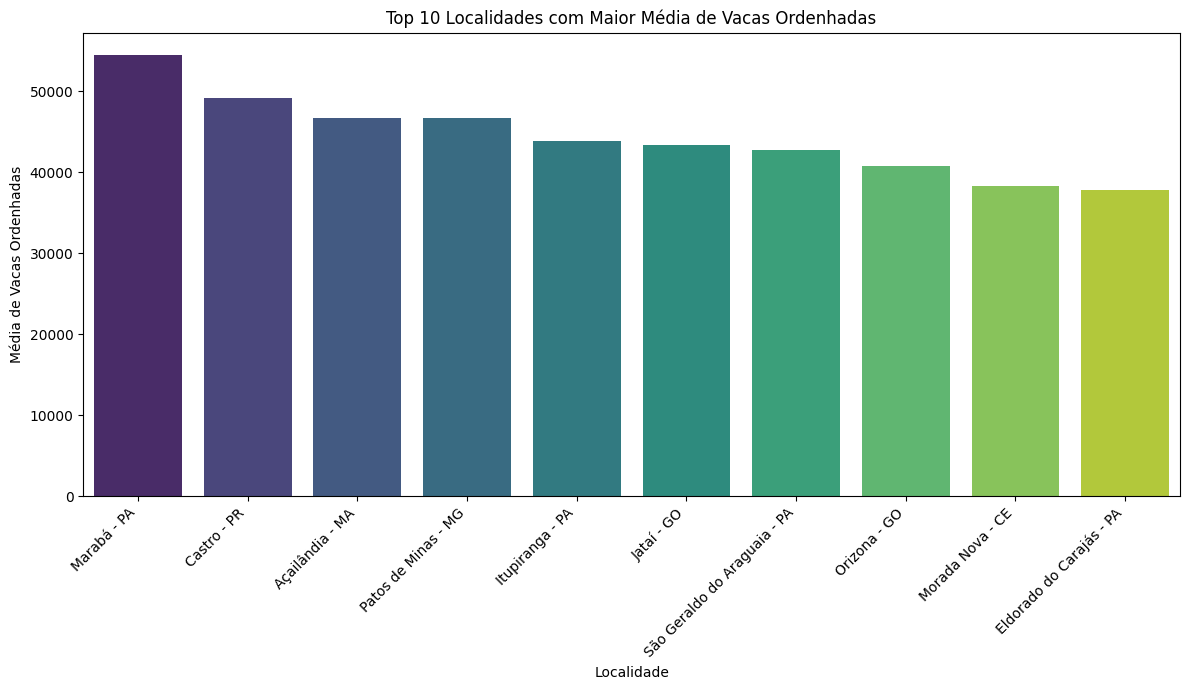

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar por média de vacas ordenhadas em ordem decrescente e pegar o top 10
top_10_localidades = avg_vacas_por_localidade.orderBy("avg(valor)", ascending=False).limit(10)

# Converter para Pandas DataFrame para facilitar a visualização
top_10_localidades_pd = top_10_localidades.toPandas()

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x="localidade_nome", y="avg(valor)", data=top_10_localidades_pd, hue="localidade_nome", palette="viridis", legend=False)
plt.title("Top 10 Localidades com Maior Média de Vacas Ordenhadas")
plt.xlabel("Localidade")
plt.ylabel("Média de Vacas Ordenhadas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

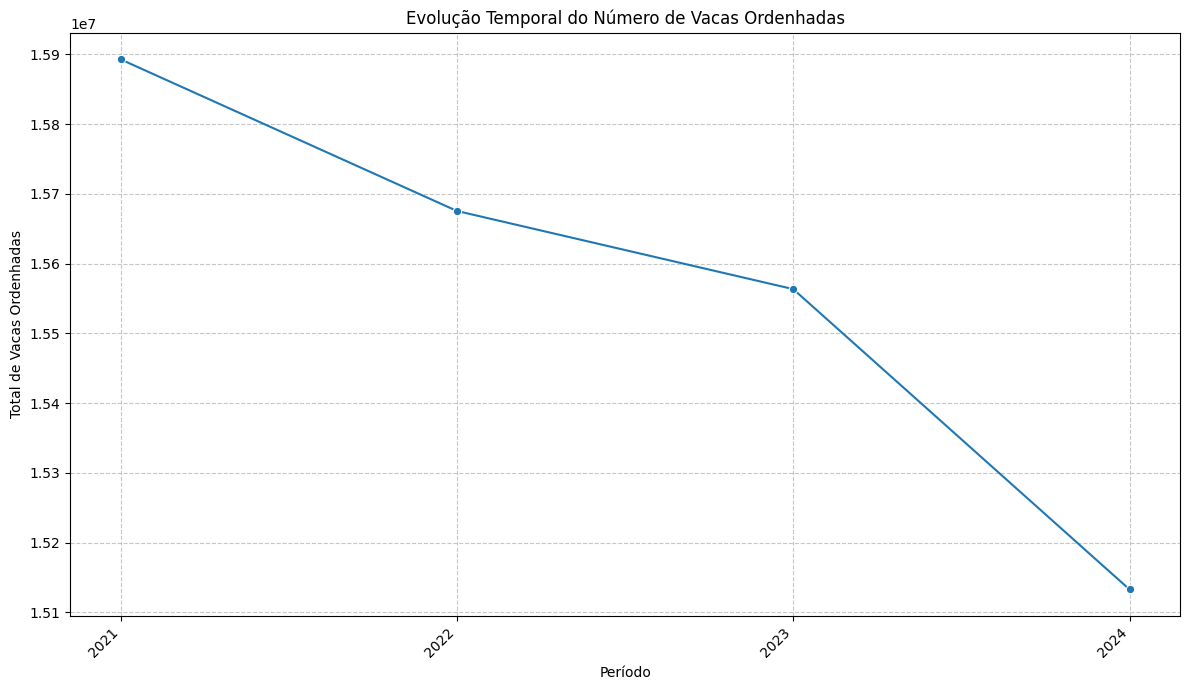

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por período e somar o valor para ver a evolução temporal
temporal_evolution = result_df.groupBy("periodo").sum("valor").orderBy("periodo")

# Converter para Pandas DataFrame para facilitar a visualização
temporal_evolution_pd = temporal_evolution.toPandas()

# Criar o gráfico de linha
plt.figure(figsize=(12, 7))
sns.lineplot(x="periodo", y="sum(valor)", data=temporal_evolution_pd, marker='o')
plt.title("Evolução Temporal do Número de Vacas Ordenhadas")
plt.xlabel("Período")
plt.ylabel("Total de Vacas Ordenhadas")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
#spark.sql("DESCRIBE FORMATTED default.bronze.conab.custo_de_producao").show(truncate=False)

In [30]:
custo_df = spark.read \
    .format("iceberg") \
    .load("default.bronze.conab.custo_de_producao")

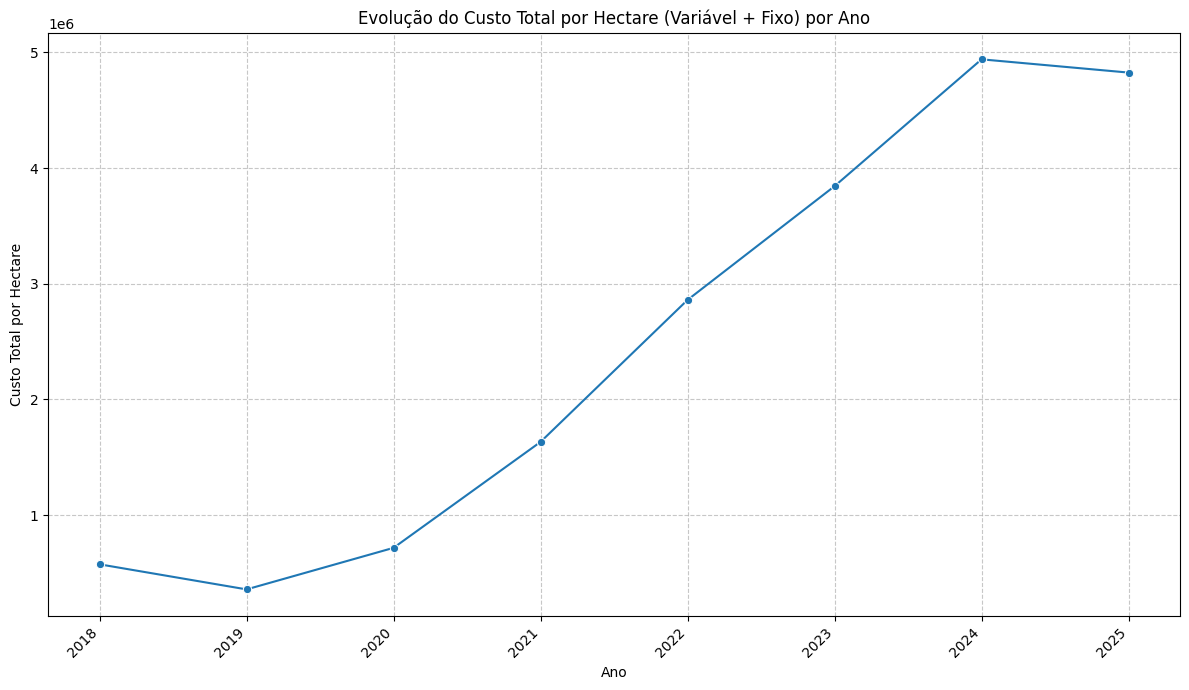

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por ano e somar os custos variáveis e fixos por hectare
custo_anual = custo_df.groupBy("ano").sum("vlr_custo_variavel_ha", "vlr_custo_fixo_ha").orderBy("ano")

# Renomear as colunas para facilitar a visualização
custo_anual = custo_anual.withColumnRenamed("sum(vlr_custo_variavel_ha)", "total_custo_variavel_ha") \
                           .withColumnRenamed("sum(vlr_custo_fixo_ha)", "total_custo_fixo_ha")

# Calcular o custo total por hectare
custo_anual = custo_anual.withColumn("total_custo_ha", custo_anual["total_custo_variavel_ha"] + custo_anual["total_custo_fixo_ha"])

# Converter para Pandas DataFrame para facilitar a visualização
custo_anual_pd = custo_anual.toPandas()

# Criar o gráfico de linha para a evolução do custo total
plt.figure(figsize=(12, 7))
sns.lineplot(x="ano", y="total_custo_ha", data=custo_anual_pd, marker='o')
plt.title("Evolução do Custo Total por Hectare (Variável + Fixo) por Ano")
plt.xlabel("Ano")
plt.ylabel("Custo Total por Hectare")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
#spark.sql("DESCRIBE FORMATTED my_catalog.default.bronze.agregado_94_vacas_ordenhadas").show(truncate=False)